In [1]:
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

In [2]:
dir = pp.COMP_PLOTS_DIR
files = [
    (dir / "criterion_values_edu1_100sim.npz", "Edu1: 100 simulations"),
    (dir / "criterion_values_edu2_100sim.npz", "Edu2: 100 simulations"),
    (dir / "criterion_values_edu3_100sim.npz", "Edu3: 100 simulations"),

    (dir / "criterion_values_edu1_1000sim.npz", "Edu1: 1000 simulations"),
    # (dir / "criterion_values_edu2_1000sim.npz", "Edu2: 1000 simulations"),
    # (dir / "criterion_values_edu3_1000sim.npz", "Edu3: 1000 simulations"),
]

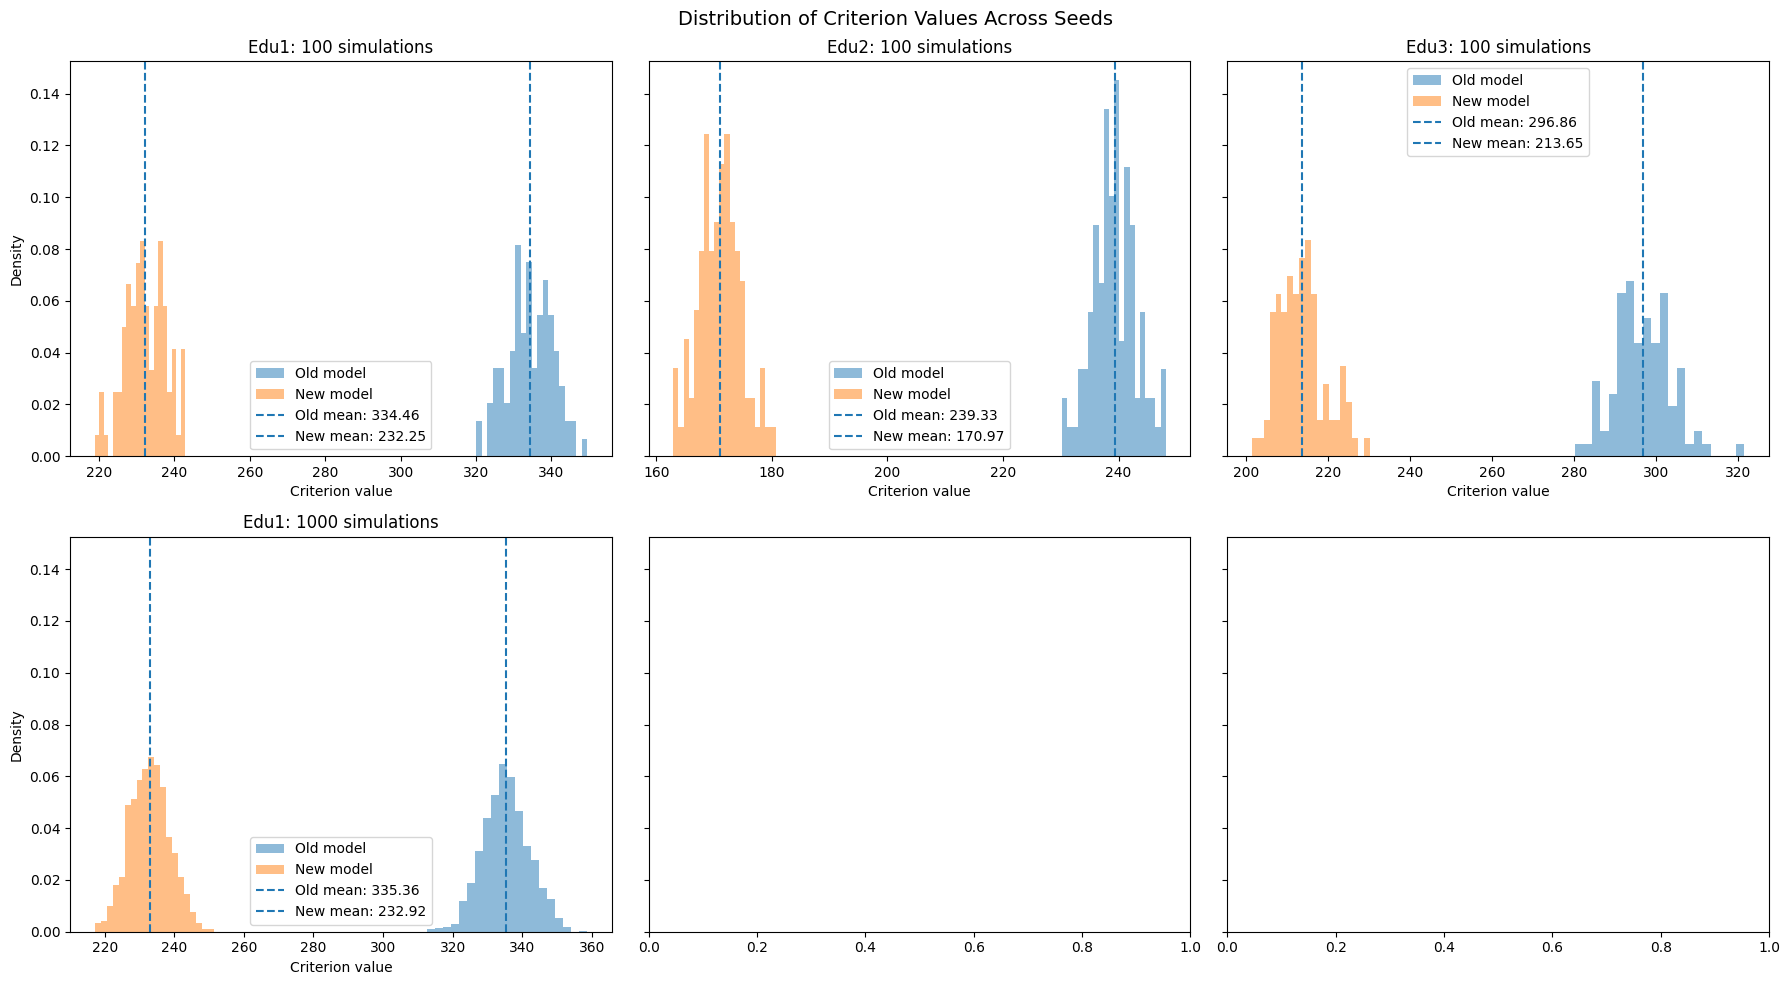

In [3]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    sharey=True
)

for ax, (file, title) in zip(axes.ravel(), files):
    data = np.load(file)

    old_vals = data["old_vals"]
    new_vals = data["new_vals"]

    ax.hist(
        old_vals,
        bins=20,
        alpha=0.5,
        density=True,
        label="Old model",
    )

    ax.hist(
        new_vals,
        bins=20,
        alpha=0.5,
        density=True,
        label="New model",
    )

    ax.axvline(
        old_vals.mean(),
        linestyle="--",
        label=f"Old mean: {old_vals.mean():.2f}"
    )

    ax.axvline(
        new_vals.mean(),
        linestyle="--",
        label=f"New mean: {new_vals.mean():.2f}"
    )

    ax.set_title(title)
    ax.set_xlabel("Criterion value")
    ax.legend()

axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Density")

fig.suptitle("Distribution of Criterion Values Across Seeds", fontsize=14)

plt.tight_layout()
plt.show()